# Philadelphia Car-Related Property Crime Analysis (2018–2025)

#### Author: Polina Adamovich

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Load and Combine Annual Crime Datasets

##### Data source https://opendataphilly.org/datasets/crime-incidents/
##### Metadata https://metadata.phila.gov/#home/datasetdetails/5543868920583086178c4f8e/representationdetails/570e7621c03327dc14f4b68d/

In [2]:
cols = [
    'objectid', # unique record identifier
    'dispatch_date',
    'text_general_code', # general crime category
    'dc_dist', # police district
]

In [3]:
files = ['2018.csv', '2019.csv', '2020.csv', '2021.csv', '2022.csv', '2023.csv', '2024.csv', '2025.csv']

In [4]:
# Filter relevant crime categories and create one list of 8 filtered DataFrames - one for each annual crime file
dfs = []

for file in files:
    df = pd.read_csv(file, usecols=cols)
    
    df = df[df['text_general_code'].isin([
        'Theft from Vehicle',
        'Motor Vehicle Theft'
    ])]
    
    dfs.append(df)

In [5]:
# Combine 8 separate yearly DataFrames into one big DataFrame
df = pd.concat(dfs, ignore_index=True)

## Data Exploration, Cleaning, & Transformation

In [6]:
# Because police district is a categorical variable, changing it from integer to string
df['dc_dist'] = df['dc_dist'].astype(str)

In [7]:
# Checking for missing values
df.isna().sum()

objectid             0
dc_dist              0
dispatch_date        0
text_general_code    0
dtype: int64

In [8]:
# Checking for duplicates
df.duplicated().sum()

0

In [9]:
# Convert the dispatch date column from text strings to a proper datetime format
df['dispatch_date'] = pd.to_datetime(
    df['dispatch_date'],
    format='mixed',
    errors='coerce'
)

In [10]:
# Extract the month and year from each date for monthly aggregation and trend analysis
df['month'] = df['dispatch_date'].dt.to_period('M')

## Visualization
### 1) Monthly Crime Trends in 2018-2025

In [11]:
# For each month and each crime type, count how many incidents happened
trend = df.groupby(['month', 'text_general_code']).size().reset_index(name='count')
trend['month'] = trend['month'].dt.to_timestamp()

In [12]:
# For each month, count all car-related property crimes together
total_trend = df.groupby('month').size().reset_index(name='count')
total_trend['month'] = total_trend['month'].dt.to_timestamp()

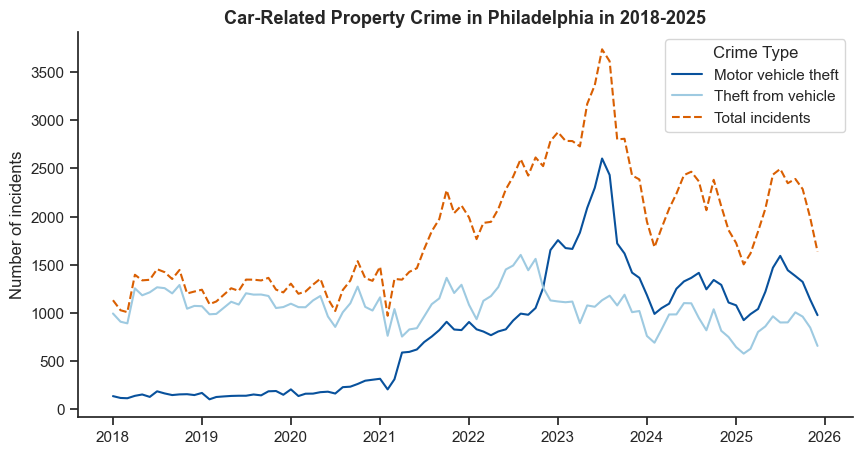

In [13]:
# Build a line chart to show monthly crime trends
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

plt.figure(figsize=(10,5))

# individual crime types
sns.lineplot(data=trend, x='month', y='count', hue='text_general_code', palette={'Motor Vehicle Theft': '#08519C', 'Theft from Vehicle': '#9ECAE1'})

# total line
sns.lineplot(data=total_trend, x='month', y='count', color='#D95F02', linestyle='--', label='Total Incidents')

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles=handles,
    labels=[
        'Motor vehicle theft',
        'Theft from vehicle',
        'Total incidents'
    ],
    title='Crime Type'
)

plt.xlabel('')
plt.ylabel('Number of incidents')
plt.title('Car-Related Property Crime in Philadelphia in 2018-2025', fontweight='bold', fontsize=13)

plt.show()

### 2) Geographic Analysis by Police District

In [14]:
# Load GeoJSON file containing Philadelphia Police District boundaries. File source https://opendataphilly.org/datasets/police-districts/
districts = gpd.read_file("Boundaries_District.geojson")
districts.head()

,objectid,dist_numc,Shape__Area,Shape__Length,geometry
0,1,24,2.431202e+07,23679.891339,"POLYGON ((-75.10549 40.01921, -75.10550 40.019..."
1,2,14,5.145272e+07,37264.007608,"POLYGON ((-75.14087 40.06422, -75.14100 40.063..."
2,3,15,4.886039e+07,35748.643667,"POLYGON ((-75.11282 40.02735, -75.11239 40.027..."
3,4,19,2.823649e+07,28526.606202,"POLYGON ((-75.22487 39.96001, -75.22621 39.960..."
4,5,01,3.416800e+07,32647.777636,"POLYGON ((-75.16896 39.92804, -75.16913 39.927..."


In [15]:
districts.dist_numc.nunique()

21

In [16]:
df.dc_dist.nunique()

22

In [17]:
df.dc_dist.unique()

array(['3', '22', '15', '39', '5', '26', '35', '7', '9', '25', '24', '14',
       '17', '2', '19', '1', '18', '6', '12', '16', '8', '77'],
      dtype=object)

The original dataset has 1 more district than the GeoJson file of police district boundaries. This is because of the merger of 6th district into 9th that happened on May 1, 2024. 

In [18]:
# Recode District 6 incidents as District 9 to reflect the May 2024 district merger
df['dc_dist_map'] = df['dc_dist'].replace({'6':'9'}).str.zfill(2)
df.dc_dist_map.nunique()

21

In [19]:
# For each police district, count the number of incidents in each crime category
# Reshape the results into a wide format for mapping and comparison

district_summary = (
    df.groupby(['dc_dist_map', 'text_general_code'])
      .size()
      .unstack()
      .reset_index()
)

district_summary.columns.name = None

In [20]:
# Create a combined total of both crime categories for each police district
district_summary['total'] = (district_summary['Motor Vehicle Theft'] + district_summary['Theft from Vehicle'])

In [21]:
# Merge crime counts with police district boundary data for mapping
districts_merged = districts.merge(
    district_summary,
    left_on='dist_numc',
    right_on='dc_dist_map',
    how='left'
)

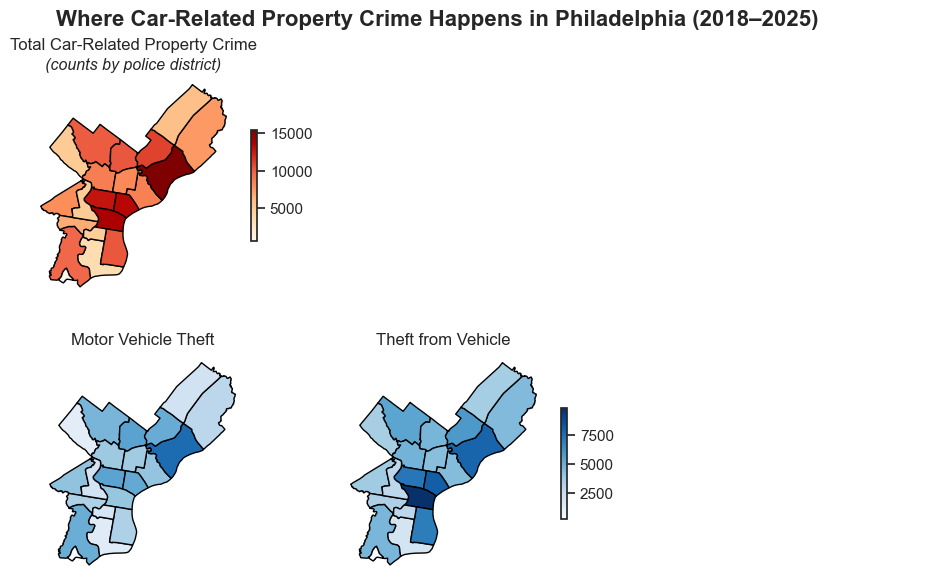

In [22]:
# Create choropleth maps to visualize where car-related property crime occurs in Philadelphia
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))

fig.suptitle('Where Car-Related Property Crime Happens in Philadelphia (2018–2025)',
             fontsize=16, fontweight='bold', y=0.98)

axes[0,1].axis('off') 
axes[0,2].axis('off') 
axes[1,2].axis('off') 

# shared range for subtype maps only
sub_min = min(districts_merged['Motor Vehicle Theft'].min(), districts_merged['Theft from Vehicle'].min()) 
sub_max = max(districts_merged['Motor Vehicle Theft'].max(), districts_merged['Theft from Vehicle'].max()) 

# total map 
districts_merged.plot(column='total', cmap='OrRd', edgecolor='black', legend=True, legend_kwds={'shrink': 0.5}, 
                      ax=axes[0,0])

axes[0,0].set_title(
    'Total Car-Related Property Crime', fontsize=12, pad=18)

axes[0,0].text(0.5, 1.01, '(counts by police district)', transform=axes[0,0].transAxes,
    ha='center', va='bottom', fontsize=11.5, style='italic')

axes[0,0].axis('off') 

# motor vehicle theft 
districts_merged.plot(column='Motor Vehicle Theft', cmap='Blues', edgecolor='black', legend=False, legend_kwds={'shrink': 0.5}, 
                      vmin=sub_min, vmax=sub_max, ax=axes[1,0]) 

axes[1,0].set_title('Motor Vehicle Theft') 
axes[1,0].axis('off') 

# theft from vehicle 

districts_merged.plot(column='Theft from Vehicle', cmap='Blues', edgecolor='black', legend=True, legend_kwds={'shrink': 0.5}, 
                      vmin=sub_min, vmax=sub_max, ax=axes[1,1]) 
axes[1,1].set_title('Theft from Vehicle') 
axes[1,1].axis('off') 

plt.subplots_adjust(wspace=0, hspace=0.25) 
plt.show()

### 3) Day-of-Week Analysis

In [23]:
# Create a day-of-week variable for analyzing weekly crime patterns
df['day_of_week'] = df['dispatch_date'].dt.day_name()

C:\Users\adamo\anaconda3\envs\cmpinf2130\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


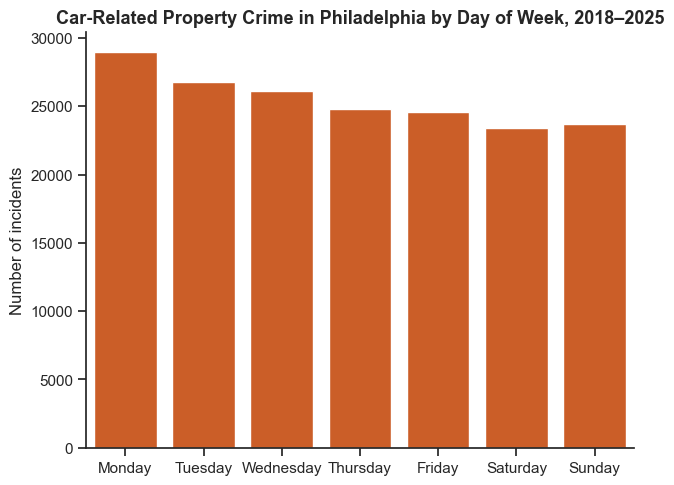

In [24]:
# Create a bar chart to visualize day-of-week crime patterns
sns.catplot(data=df, x='day_of_week', kind='count', color='#E6550D', aspect=1.3)

plt.xlabel('')
plt.ylabel('Number of incidents')
plt.title('Car-Related Property Crime in Philadelphia by Day of Week, 2018–2025', fontweight='bold', fontsize=13)
plt.show()

## Conclusions

Analysis of Philadelphia Police Department incident data from 2018–2025 revealed three key patterns in car-related property crime:

1. **The overall increase in car-related property crime was driven primarily by motor vehicle theft.**
Between 2018 and 2021, incident levels remained relatively stable. Beginning in 2021, motor vehicle theft increased sharply, eventually surpassing theft-from-vehicle incidents and peaking in 2023. Although theft levels declined afterward, they remained substantially above pre-2021 levels by the end of the study period.

2. **Crime patterns varied geographically across the city.**
Northeast Philadelphia experienced the highest concentration of car-related property crime overall, with elevated levels of both motor vehicle theft and theft from vehicles. Center City and Old City areas showed particularly high concentrations of theft-from-vehicle incidents, suggesting different spatial patterns across offense types.

3. **Temporal variation by day of week was limited.**
Incident counts were relatively consistent throughout the week, indicating that car-related property crime is not strongly associated with a particular day. This suggests that vehicle owners face a similar level of risk regardless of when they park.